<a href="https://colab.research.google.com/github/milleau98/2026-gig-data-analysis/blob/main/notebooks/data-analyses/correlation_analyses.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [16]:
!pip install -q pandas numpy matplotlib scipy seaborn


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [8]:
import os

# See what folders/files exist in the repo root
print(os.listdir('/workspaces/2026-gig-data-analysis'))
print(os.listdir('/workspaces/2026-gig-data-analysis/data'))
print(os.listdir('/workspaces/2026-gig-data-analysis/data/yfinance'))

['.git', 'notebooks', '.gitignore', 'data', 'README.md']
['fred', 'yfinance', 'google_trends', 'edgar_sec', 'merged_sec_yfin']
['gig_yfinance_annually.csv', 'sp500_yfinance_quarterly.csv', 'yfinance_column_mapping.csv', 'sp500_yfinance_annually.csv', 'gig_yfinance_raw.csv', 'gig_yfinance_quarterly.csv', 'gig_yfinance_monthly.csv', 'sp500_yfinance_monthly.csv']


In [9]:
import pandas as pd

# stock price
gig_stock_df_annually = pd.read_csv('../../data/yfinance/gig_yfinance_annually.csv', parse_dates=['Date'])
gig_stock_df_quarterly = pd.read_csv('../../data/yfinance/gig_yfinance_quarterly.csv', parse_dates=['Date'])
gig_stock_df_monthly = pd.read_csv('../../data/yfinance/gig_yfinance_monthly.csv', parse_dates=['Date'])
sp500_stock_df_annually = pd.read_csv('../../data/yfinance/sp500_yfinance_annually.csv', parse_dates=['Date'])
sp500_stock_df_quarterly = pd.read_csv('../../data/yfinance/sp500_yfinance_quarterly.csv', parse_dates=['Date'])
sp500_stock_df_monthly = pd.read_csv('../../data/yfinance/sp500_yfinance_monthly.csv', parse_dates=['Date'])

# Combine gig and sp500 stock data
stock_df_annually = pd.concat([gig_stock_df_annually, sp500_stock_df_annually])
stock_df_quarterly = pd.concat([gig_stock_df_quarterly, sp500_stock_df_quarterly])
stock_df_monthly = pd.concat([gig_stock_df_monthly, sp500_stock_df_monthly])


# google trend data
google_df_annually = pd.read_csv('../../data/google_trends/google_trends_annual.csv', parse_dates=['date'])
google_df_quarterly = pd.read_csv('../../data/google_trends/google_trends_quarterly.csv', parse_dates=['date'])
google_df_monthly = pd.read_csv('../../data/google_trends/google_trends_monthly.csv', parse_dates=['date'])

# FRED data
fred_df_annually = pd.read_csv('../../data/fred/fred_annual_data.csv', parse_dates=['date'])
fred_df_quarterly = pd.read_csv('../../data/fred/fred_quarterly_data.csv', parse_dates=['date'])
fred_df_monthly = pd.read_csv('../../data/fred/fred_monthly_data.csv', parse_dates=['date'])


stock_df_quarterly.head()



,Date,Quarter,Year,Company,Ticker,industryKey,sectorKey,Close,Volume
0,2018-12-31,4,2018,Upwork,UPWK,internet-content-information,communication-services,18.110001,337200.0
1,2019-03-31,1,2019,Upwork,UPWK,internet-content-information,communication-services,19.139999,1189400.0
2,2019-06-30,2,2019,Upwork,UPWK,internet-content-information,communication-services,16.080000,6966900.0
3,2019-09-30,3,2019,Upwork,UPWK,internet-content-information,communication-services,13.310000,1698000.0
4,2019-12-31,4,2019,Upwork,UPWK,internet-content-information,communication-services,10.670000,1182600.0


In [10]:
google_df_annually_long = google_df_annually.melt(
    id_vars=['year'],
    value_vars= ['Uber','Lyft','DoorDash','Instacart','Grubhub','Fiverr','Upwork','side hustle','gig','Herbalife','Primerica','Tupperware','Avon','Etsy', 'Shopify', 'Udemy'],
    var_name = 'company',
    value_name = 'SearchInterest'
)

google_df_quarterly_long = google_df_quarterly.melt(
    id_vars=['year', 'quarter'],
    value_vars= ['Uber','Lyft','DoorDash','Instacart','Grubhub','Fiverr','Upwork','side hustle','gig','Herbalife','Primerica','Tupperware','Avon','Etsy', 'Shopify', 'Udemy'],
    var_name = 'company',
    value_name = 'SearchInterest'
)

google_df_monthly_long = google_df_monthly.melt(
    id_vars=['year', 'month'],
    value_vars= ['Uber','Lyft','DoorDash','Instacart','Grubhub','Fiverr','Upwork','side hustle','gig','Herbalife','Primerica','Tupperware','Avon','Etsy', 'Shopify', 'Udemy'],
    var_name = 'company',
    value_name = 'SearchInterest'
)


In [11]:
# rename columns to match across datasets
gig_stock_df_annually = gig_stock_df_annually.rename(columns={'Year': 'year'})
gig_stock_df_quarterly = gig_stock_df_quarterly.rename(columns={'Year': 'year'})
gig_stock_df_monthly = gig_stock_df_monthly.rename(columns={'Year': 'year'})
sp500_stock_df_annually = sp500_stock_df_annually.rename(columns={'Year': 'year'})
sp500_stock_df_quarterly = sp500_stock_df_quarterly.rename(columns={'Year': 'year'})
sp500_stock_df_monthly = sp500_stock_df_monthly.rename(columns={'Year': 'year'})

stock_df_annually = stock_df_annually.rename(columns={'Year':'year', 'Company':'company'})
stock_df_quarterly = stock_df_quarterly.rename(columns={'Year':'year', 'Quarter':'quarter', 'Company':'company'})
stock_df_monthly = stock_df_monthly.rename(columns={'Year':'year', 'Month':'month', 'Company':'company'})

gig_stock_df_quarterly = gig_stock_df_quarterly.rename(columns={'Quarter': 'quarter'})
gig_stock_df_monthly = gig_stock_df_monthly.rename(columns={'Month': 'month'})
sp500_stock_df_quarterly = sp500_stock_df_quarterly.rename(columns={'Quarter': 'quarter'})
sp500_stock_df_monthly = sp500_stock_df_monthly.rename(columns={'Month': 'month'})

# only keep necessary columns before merging
annual_stock_cols = ['year','company','Close','Volume']
annual_fred_cols = ['year','cpi_inflation_data_annual','unemployment_data_monthly']
quarterly_stock_cols = ['year','quarter', 'company','Close','Volume']
quarterly_fred_cols = ['year', 'quarter', 'cpi_inflation_data_annual','unemployment_data_monthly']
monthly_stock_cols = ['year', 'month', 'company','Close','Volume']
monthly_fred_cols = ['year', 'month', 'cpi_inflation_data_annual','unemployment_data_monthly']

stock_df_annually = stock_df_annually[annual_stock_cols]
stock_df_quarterly = stock_df_quarterly[quarterly_stock_cols]
stock_df_monthly = stock_df_monthly[monthly_stock_cols]
fred_df_annually = fred_df_annually[annual_fred_cols]
fred_df_quarterly = fred_df_quarterly[quarterly_fred_cols]
fred_df_monthly = fred_df_monthly[monthly_fred_cols]
google_df_annually_long = google_df_annually_long[['year','company','SearchInterest']]
google_df_quarterly_long = google_df_quarterly_long[['year', 'quarter', 'company','SearchInterest']]
google_df_monthly_long = google_df_monthly_long[['year', 'month', 'company','SearchInterest']]

# gig stocks merged with all other data
#gig_merged_df_annually = gig_stock_df_annually.merge(google_df_annually_long, on='year', how='left').merge(fred_df_annually, on='year', how='left')
#gig_merged_df_quarterly = gig_stock_df_quarterly.merge(google_df_quarterly_long, on=['year', 'quarter'], how='left').merge(fred_df_quarterly, on=['year', 'quarter'], how='left')
#gig_merged_df_monthly = gig_stock_df_monthly.merge(google_df_monthly_long, on=['year', 'month'], how='left').merge(fred_df_monthly, on=['year', 'month'], how='left')

# sp500 stocks merged with all other data
#sp500_merged_df_annually = sp500_stock_df_annually.merge(google_df_annually_long, on='year', how='left').merge(fred_df_annually, on='year', how='left')
#sp500_merged_df_quarterly = sp500_stock_df_quarterly.merge(google_df_quarterly_long, on=['year', 'quarter'], how='left').merge(fred_df_quarterly, on=['year', 'quarter'], how='left')
#sp500_merged_df_monthly = sp500_stock_df_monthly.merge(google_df_monthly_long, on=['year', 'month'], how='left').merge(fred_df_monthly, on=['year', 'month'], how='left')


merged_df_annually = (
    stock_df_annually
    .merge(google_df_annually_long, on=['year','company'], how='left')
    .merge(fred_df_annually, on='year', how='left')
)

merged_df_quarterly = (
    stock_df_quarterly
    .merge(google_df_quarterly_long, on=['year','company','quarter'], how='left')
    .merge(fred_df_quarterly, on=['year','quarter'], how='left')
)

merged_df_monthly = (
    stock_df_monthly
    .merge(google_df_monthly_long, on=['year','company','month'], how='left')
    .merge(fred_df_monthly, on=['year','month'], how='left')
)

merged_df_annually.head(75)

,year,company,Close,Volume,SearchInterest,cpi_inflation_data_annual,unemployment_data_monthly
0,2018,Upwork,18.110001,337200.0,1.500000,2.442583,3.891667
1,2019,Upwork,10.670000,1182600.0,1.750000,1.812210,3.675000
2,2020,Upwork,34.520000,1485200.0,1.833333,1.233584,8.100000
3,2021,Upwork,34.160000,672300.0,1.083333,4.697859,5.350000
4,2022,Upwork,10.440000,1120800.0,2.500000,8.002800,3.650000
...,...,...,...,...,...,...,...
70,2010,Herbalife,16.037758,728800.0,3.000000,1.640043,9.608333
71,2011,Herbalife,24.540632,1252000.0,3.500000,3.156842,8.933333
72,2012,Herbalife,16.014555,32691000.0,4.666667,2.069337,8.075000
73,2013,Herbalife,39.174538,2007600.0,7.000000,1.464833,7.358333


In [ ]:
#annual_cols_to_keep = ['year', 'company', 'Close', 'Volume', 'cpi_inflation_data_annual', 'unemployment_data_monthly', 'SearchInterest']

#gig_cleaned_df_annually = gig_merged_df_annually[annual_cols_to_keep].copy()
#sp500_cleaned_df_annually = sp500_merged_df_annually[annual_cols_to_keep].copy()

#gig_cleaned_df_annually.head()

In [ ]:
#quarterly_cols_to_keep = ['year','quarter', 'company', 'Close', 'Volume', 'cpi_inflation_data_annual', 'unemployment_data_monthly', 'SearchInterest']

#gig_cleaned_df_quarterly = gig_merged_df_quarterly[quarterly_cols_to_keep].copy()
#sp500_cleaned_df_quarterly = sp500_merged_df_quarterly[quarterly_cols_to_keep].copy()

#gig_cleaned_df_quarterly.head(50)

In [ ]:
#monthly_cols_to_keep = ['year','month', 'company', 'Close', 'Volume', 'cpi_inflation_data_annual', 'unemployment_data_monthly', 'SearchInterest']

#gig_cleaned_df_monthly = gig_merged_df_monthly[monthly_cols_to_keep].copy()
#sp500_cleaned_df_monthly = sp500_merged_df_monthly[monthly_cols_to_keep].copy()

#gig_cleaned_df_monthly.head()

# Correlation Matrix

In [13]:
corr_df_annually = merged_df_annually[
    ['Close', 'Volume', 'cpi_inflation_data_annual',
     'unemployment_data_monthly', 'SearchInterest']
]

corr_df_annually.head()

,Close,Volume,cpi_inflation_data_annual,unemployment_data_monthly,SearchInterest
0,18.110001,337200.0,2.442583,3.891667,1.500000
1,10.670000,1182600.0,1.812210,3.675000,1.750000
2,34.520000,1485200.0,1.233584,8.100000,1.833333
3,34.160000,672300.0,4.697859,5.350000,1.083333
4,10.440000,1120800.0,8.002800,3.650000,2.500000


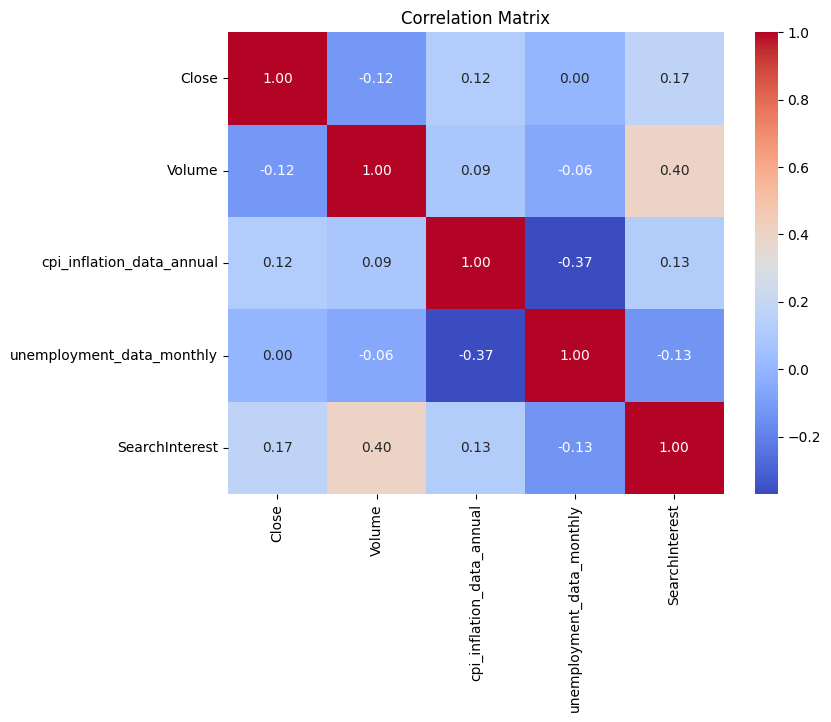

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

# -------------------------------
# Choose your dataset: quarterly or monthly
# -------------------------------
df = merged_df_quarterly  # or merged_df_monthly

# -------------------------------
# Select the relevant columns
# -------------------------------
# Adjust column names to match your dataset
cols_to_corr = [
    'Close',                    # stock price
    'Volume',                   # stock volume
    'cpi_inflation_data_annual',# inflation
    'unemployment_data_monthly',# unemployment rate
    'SearchInterest'            # google search interest
]

corr_df = df[cols_to_corr].dropna()  # remove rows with missing values

# -------------------------------
# Compute correlation matrix
# -------------------------------
corr_matrix = corr_df.corr()

# -------------------------------
# Plot heatmap
# -------------------------------
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

# CCF: Lag Analysis - Search Interest & Stock Price

/tmp/ipykernel_6717/2290319607.py:13: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  y = df['Close'].fillna(method='ffill')


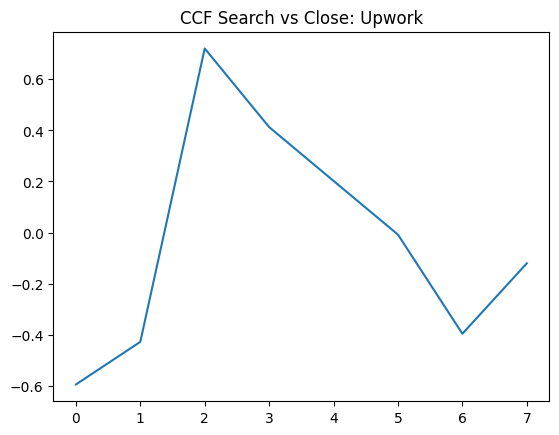

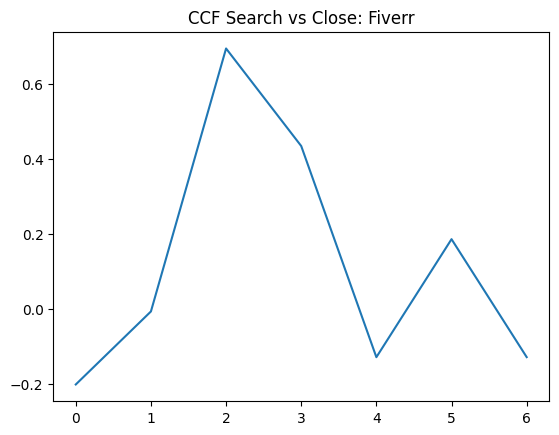

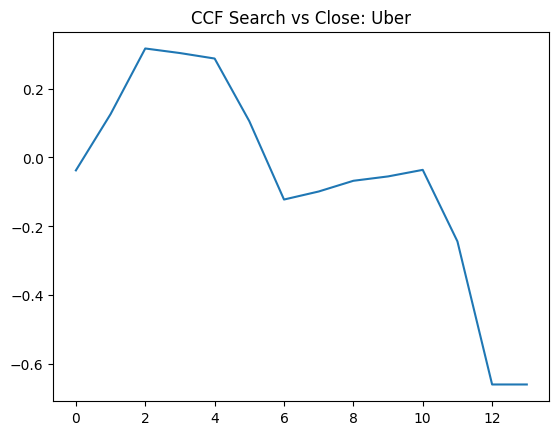

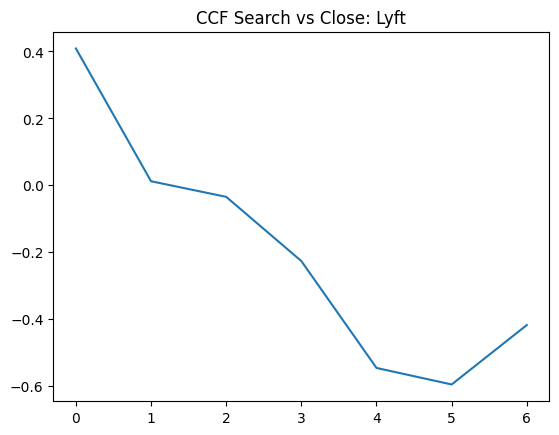

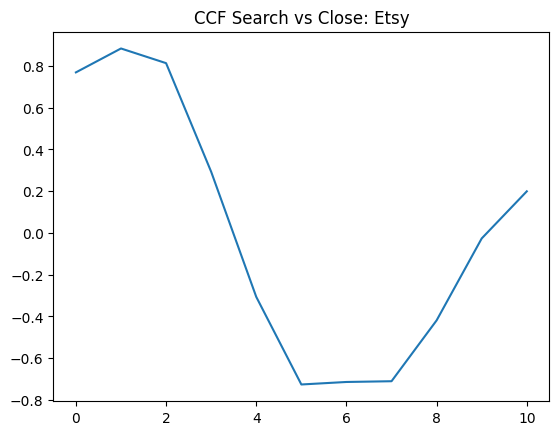

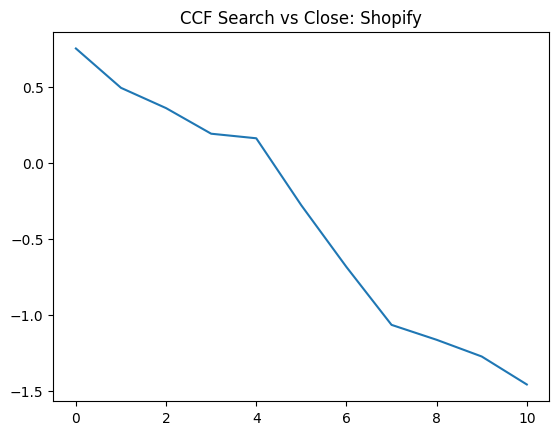

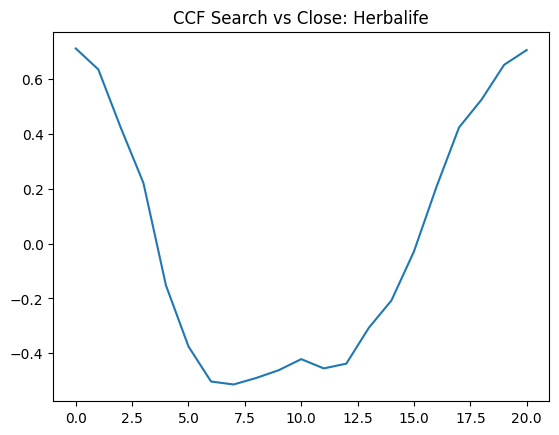

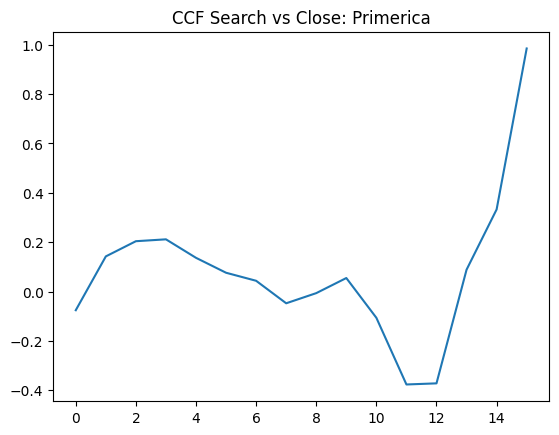

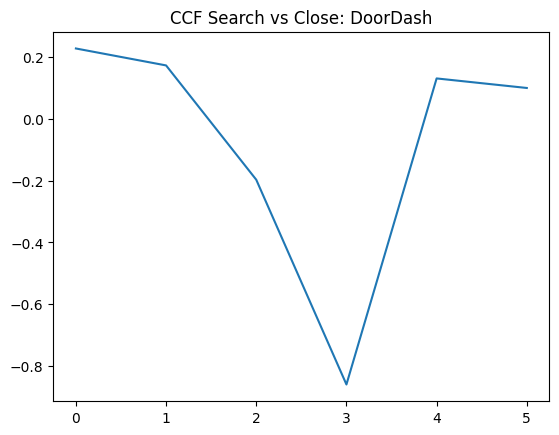

In [ ]:
from statsmodels.tsa.stattools import ccf
import matplotlib.pyplot as plt

# looping through companies to ensure correlation is set up correctly
companies = merged_df_annually['company'].unique()

for c in companies:
    df = merged_df_annually[merged_df_annually['company'] == c]
    df = df.sort_values('year').set_index('year')

    if df['SearchInterest'].notna().sum() > 5:
        x = df['SearchInterest'].fillna(0)
        y = df['Close'].fillna(method='ffill')

        ccf_vals = ccf(x, y)

        plt.plot(ccf_vals)
        plt.title(f'CCF Search vs Close: {c}')
        plt.show()

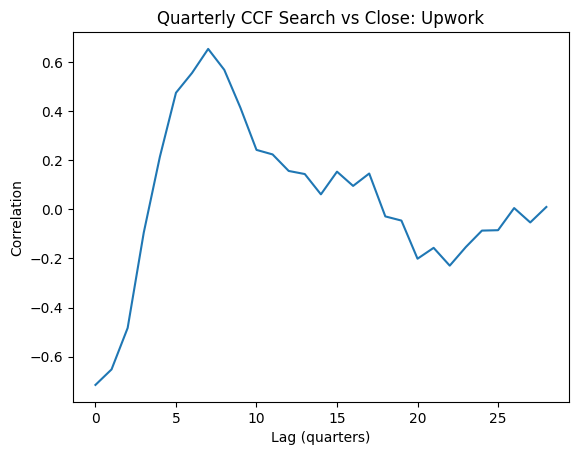

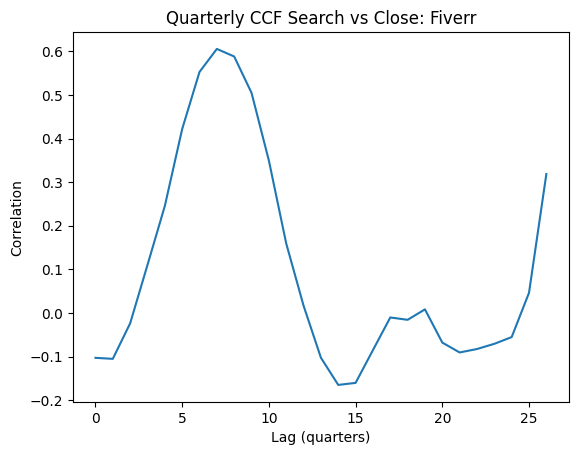

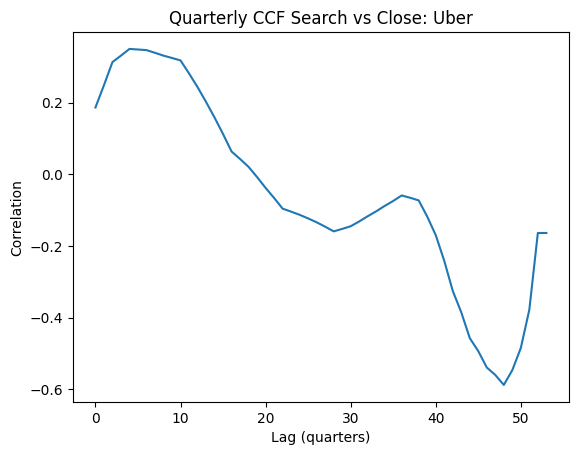

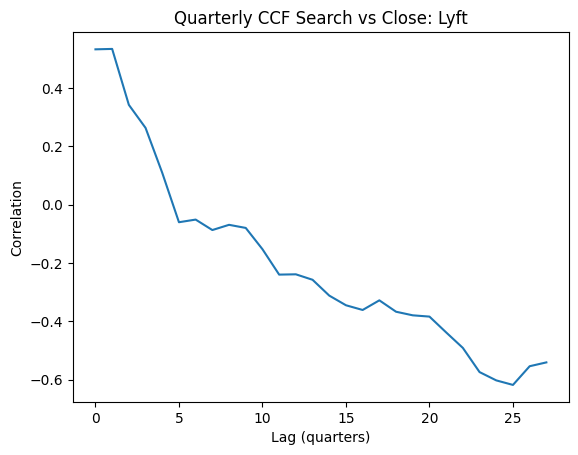

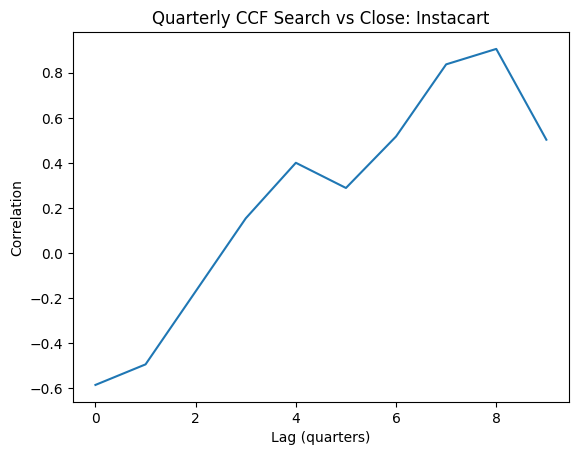

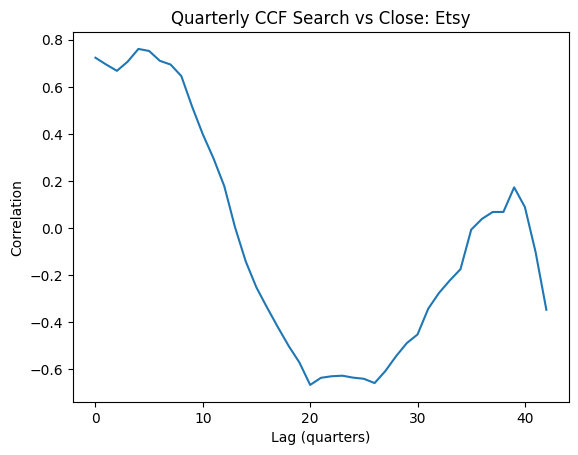

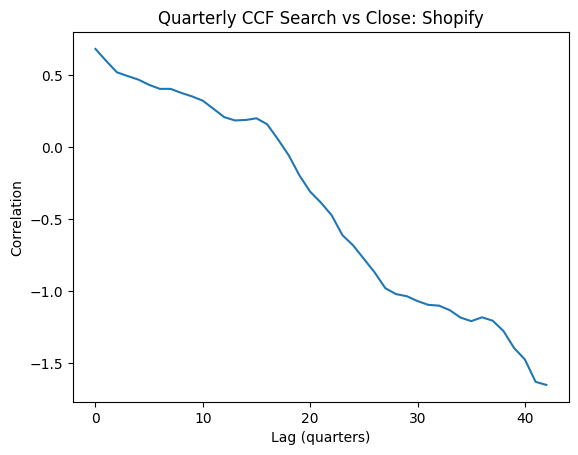

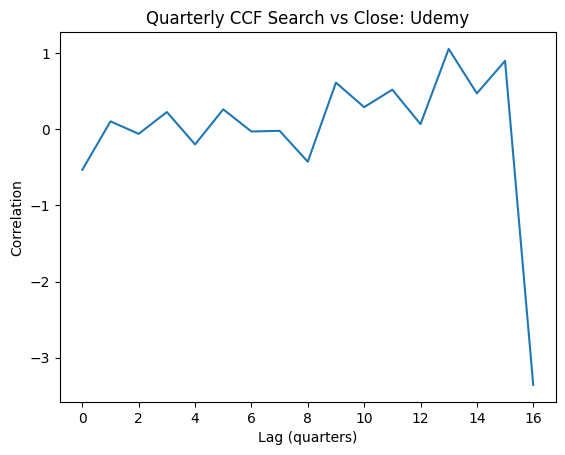

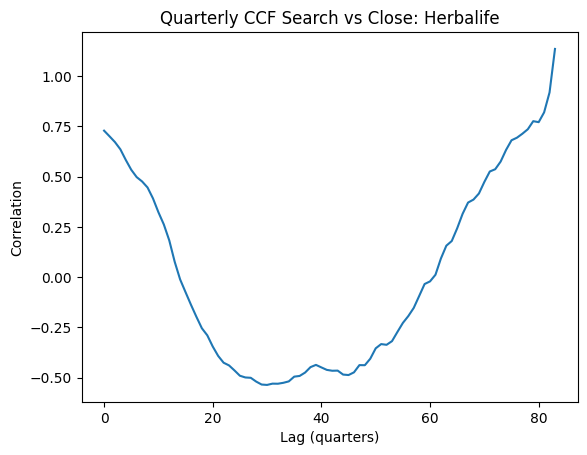

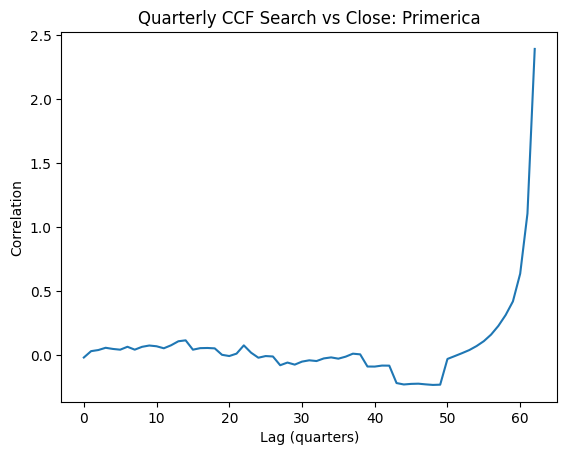

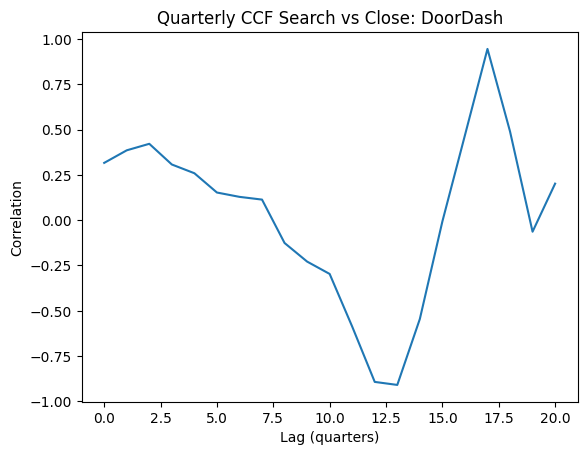

In [ ]:
# quarterly
companies = merged_df_quarterly['company'].unique()

for c in companies:
    df = merged_df_quarterly[merged_df_quarterly['company'] == c].copy()

    # create time index
    df['time'] = df['year'].astype(str) + 'Q' + df['quarter'].astype(str)
    df = df.sort_values(['year', 'quarter'])
    df = df.set_index('time')

    if df['SearchInterest'].notna().sum() > 5:
        x = df['SearchInterest'].fillna(0)
        y = df['Close'].ffill()

        ccf_vals = ccf(x, y)

        plt.plot(ccf_vals)
        plt.title(f'Quarterly CCF Search vs Close: {c}')
        plt.xlabel('Lag (quarters)')
        plt.ylabel('Correlation')
        plt.show()

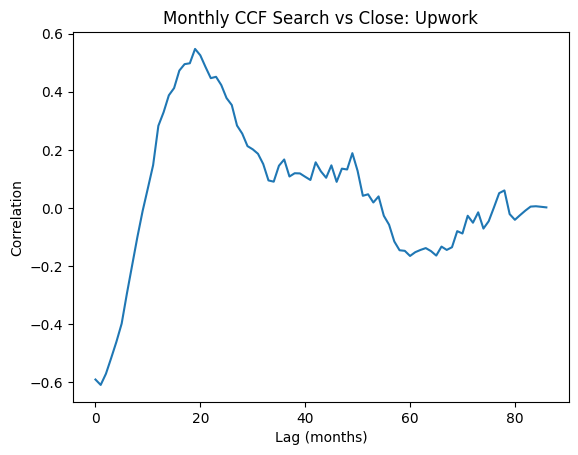

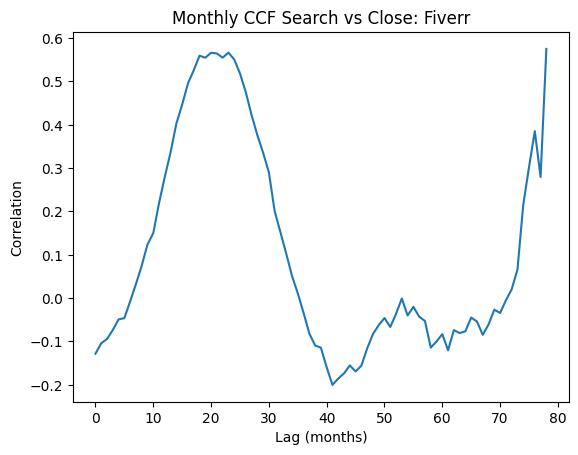

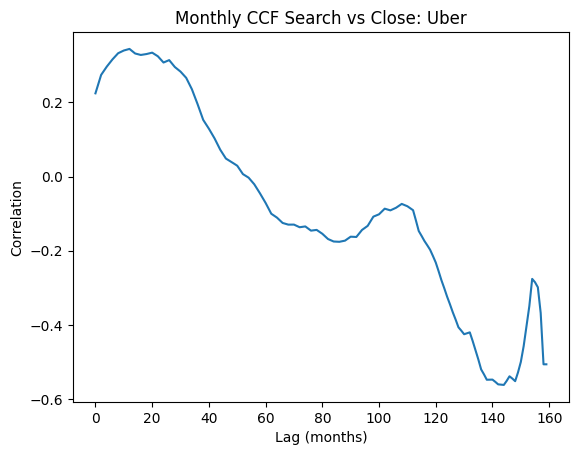

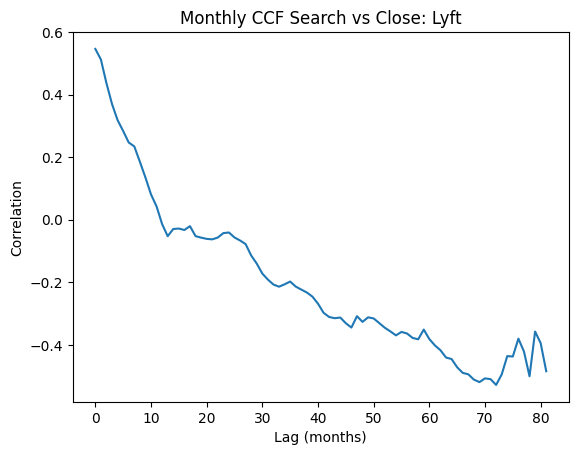

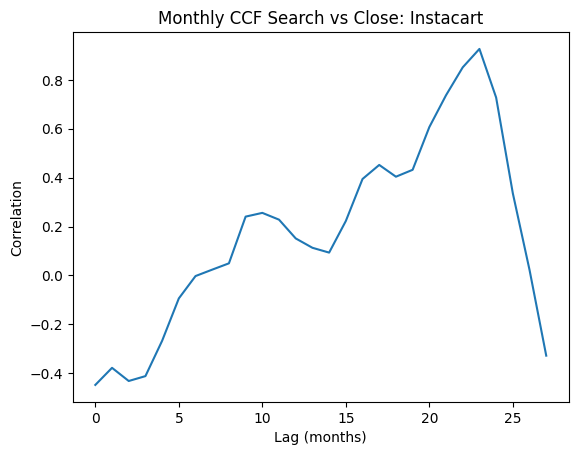

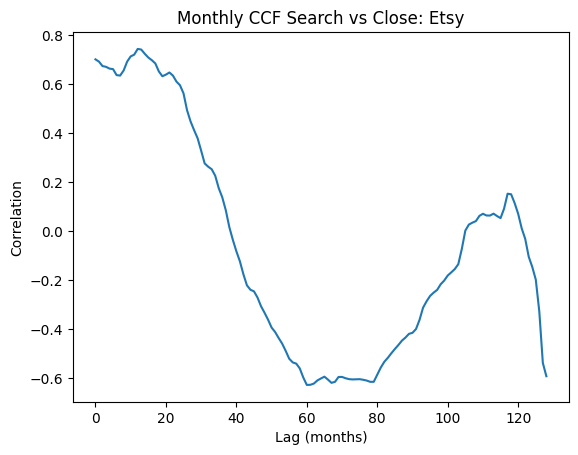

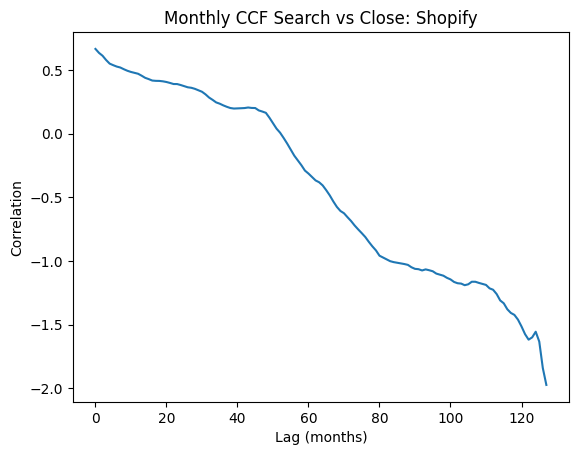

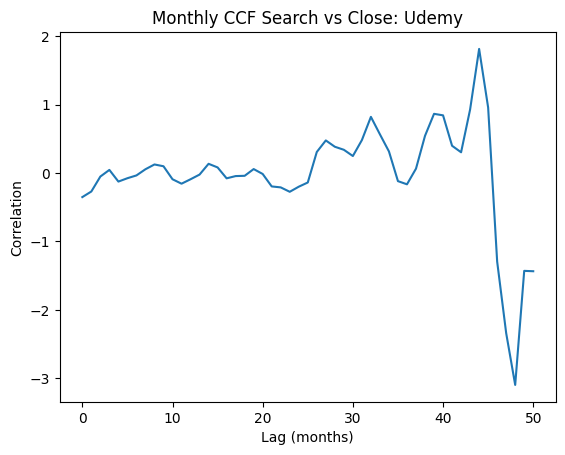

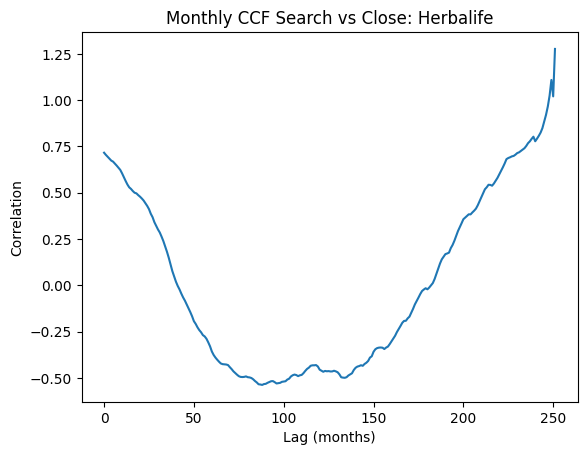

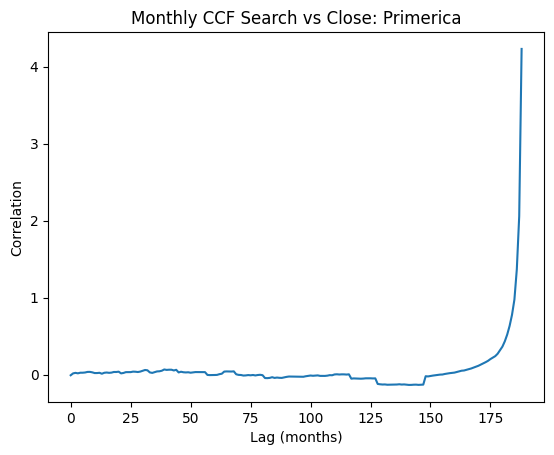

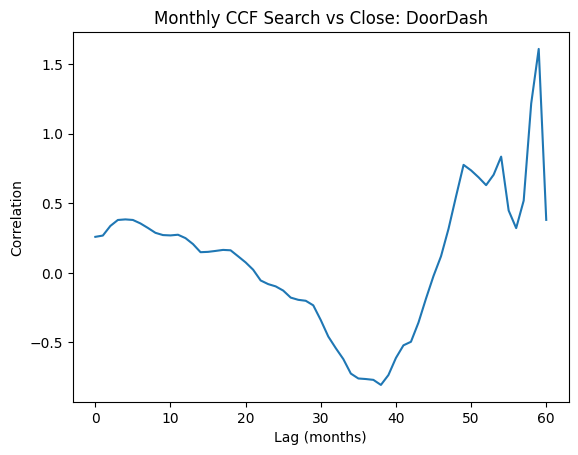

In [ ]:
# monthly
companies = merged_df_monthly['company'].unique()

for c in companies:
    df = merged_df_monthly[merged_df_monthly['company'] == c].copy()

    # create time index
    df['time'] = df['year'].astype(str) + '-' + df['month'].astype(str)
    df = df.sort_values(['year', 'month'])
    df = df.set_index('time')

    if df['SearchInterest'].notna().sum() > 10:
        x = df['SearchInterest'].fillna(0)
        y = df['Close'].ffill()

        ccf_vals = ccf(x, y)

        plt.plot(ccf_vals)
        plt.title(f'Monthly CCF Search vs Close: {c}')
        plt.xlabel('Lag (months)')
        plt.ylabel('Correlation')
        plt.show()